# Robustness to partial observations: PSS partial observations

A key question for practical applicability is how inference behaves when observations are incomplete.
Transcriptomic experiments capture snapshots of cellular states at discrete time points: the dynamics
unfolding between successive snapshots are unobserved, and any given time point may lack measurements
for some receptor or ligand states. Such gaps can arise from inconclusive binarization, sequencing
dropout, or insufficient coverage.

In our framework, an observation corresponds to a **pseudo-steady state (PSS)** — a snapshot of the
system in which receptors and ligands have reached a stable configuration given the current signaling
context. The inference is driven by a sequence of such PSS snapshots over time. Partial observations
can therefore arise at two levels:

- **PSS partial observations**: within a given PSS, the state of some components (all receptors or
  all ligands at that time point) is unknown.
- **PSS sequence partial observations**: an entire time point is omitted from the sequence, so the
  transition between its flanking PSS snapshots must be explained by an arbitrary number of
  intermediate steps.

We assess robustness to each type in turn. This notebook focuses on **PSS partial observations**,
holding out either all receptors or all ligands at a single time point, specifically $R(T_2)$,
$R(T_3)$, $R(T_4)$, $L(T_3)$, $L(T_4)$, or $L(T_5)$, and measuring how the inferred influence
graph ensemble compares to the complete-observation reference. PSS sequence partial observations are
treated in a companion notebook.

## Influence graph structure of the complete-observation ensemble

Before evaluating robustness to missing data, we characterize the structure of the influence graphs
inferred from the full observation sequence — the reference ensemble against which all
partial-observation results are compared.

BoNesis exhaustively enumerates all minimal influence graphs consistent with the complete PSS
sequence, producing 448 distinct graphs. We aggregate them into a single stacked influence graph
where each edge carries the count of networks in which it appears. This immediately reveals a
structural split that maps onto the bipartite architecture of the framework:

- **R → L edges** (within-cell, ligand secretion rules) are highly concentrated: most appear in all
  448 networks, meaning the observations tightly constrain how each cell translates receptor inputs
  into secretion outputs.
- **L → R edges** (cross-cell, receptor activation rules) are more variable: multiple alternative
  wiring patterns are compatible with the observed dynamics, reflecting the intrinsic
  under-determination of cross-cell signaling by temporal snapshots alone.

We distinguish **core edges** — present in all 448 influence graphs and therefore structurally
necessary for the observed dynamics — from **variable edges**, present in a subset and representing
equivalent alternative wirings. The complete ensemble contains 13 core edges and 21 variable edges
(34 total). This partition is the reference for all subsequent robustness analyses: under partial
observations, we track whether core edges are preserved, weakened to variable status, or lost, and
whether new edges become admissible as constraints are relaxed.

## PSS partial observations

We evaluate six holdout conditions: $R(T_2)$, $R(T_3)$, $R(T_4)$ (all receptors unobserved at that
time point) and $L(T_3)$, $L(T_4)$, $L(T_5)$ (all ligands unobserved). For each condition, we run
the full BoNesis inference pipeline on the reduced observation set and compare the resulting
influence graph ensemble to the 448-graph complete-observation reference using the following edge
classification:

- **Core → Recovered**: core edges in the complete ensemble that remain present in the partial ensemble.
- **Core → Lost**: core edges that disappear under the reduced constraints.
- **Variable → Recovered**: variable edges that remain present.
- **Variable → Lost**: variable edges that disappear.
- **New**: edges absent from the complete ensemble that become admissible under the reduced
  constraints — an expected consequence of relaxing observations, as fewer constraints allow a
  larger solution space.

### Influence graph comparison across holdout conditions

In [1]:
from Inference_CCC import *

### Generate full observations, to compare to the PSS partial observation 

In [2]:
# Complete observations with one state changed at each time step
R_A = {
        'T1': {'R1_A': 1, 'R2_A': 0},
        'T2': {'R1_A': 1, 'R2_A': 0},
        'T3': {'R1_A': 1, 'R2_A': 1},
        'T4': {'R1_A': 1, 'R2_A': 1},
        'T5': {'R1_A': 0, 'R2_A': 1},
        'T6': {'R1_A': 0, 'R2_A': 1},
        'T7': {'R1_A': 0, 'R2_A': 1},
        'T8': {'R1_A': 0, 'R2_A': 1}
    }

R_B = {
        'T1': {'R1_B': 1, 'R2_B': 0},
        'T2': {'R1_B': 1, 'R2_B': 0},
        'T3': {'R1_B': 0, 'R2_B': 1},
        'T4': {'R1_B': 0, 'R2_B': 1},
        'T5': {'R1_B': 0, 'R2_B': 0},
        'T6': {'R1_B': 0, 'R2_B': 0},
        'T7': {'R1_B': 1, 'R2_B': 1},
        'T8': {'R1_B': 1, 'R2_B': 1}
    }

L_A = {
        'T1': {'L1_A': 1, 'L2_A': 0, 'L3_A': 0, 'L4_A': 0},
        'T2': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T3': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T4': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T5': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T6': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T7': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T8': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1}
    }

L_B = {
        'T1': {'L1_B': 1, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T2': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T3': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T4': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T5': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T6': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T7': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T8': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 1}
    }

R = {"A": R_A, "B": R_B}
L = {"A": L_A, "B": L_B}

# Create the observation data
obs_df, complete_compr_obs_df, cells, influences, all_receptors, all_ligands = create_observation_data(R, L)


In [3]:
complete_compr_obs_df 

,R1_A,R2_A,R1_B,R2_B,L1_A,L2_A,L3_A,L4_A,L1_B,L2_B,L3_B,L4_B
T1,1,0,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
T2,1,1,0,1,1,1,0,0,1,1,0,0
T3,0,1,0,0,1,1,1,0,0,0,1,0
T4,0,1,1,1,0,0,0,1,0,0,0,0
T5,<NA>,<NA>,<NA>,<NA>,0,0,0,1,0,0,0,1


In [4]:
results_complete_obs = run_full_workflow(complete_compr_obs_df, cells, influences, limit_igs=500, limit_bns=0, details=False)

Enumerating up to 500 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:01, 234.68it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [5]:
limit_igs = 1000
limit_bns = 0

# Introducing missing information in the observations

For each PSS, either the receptors or the ligands information is taken off form the observations (compr_obs_df) and the inference is done with it. \
The influence graphs are plotted, and then compared to the ones obtained with all observations 



## Functions for the plot 

In [6]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def classify_edges(igs_complete, igs_partial):
    """
    Classify all edges relative to the complete ensemble.
    An edge "exists" in an ensemble if it appears in at least one model.
    """
    n_complete = len(igs_complete)

    def count_edges(igs):
        c = Counter()
        for ig in igs:
            for src, tgt, data in ig.edges(data=True):
                sign = data.get("sign", data.get("weight", 1))
                c[(src, tgt, sign)] += 1
        return c

    counts_c = count_edges(igs_complete)
    counts_p = count_edges(igs_partial)

    core_edges     = {e for e, c in counts_c.items() if c == n_complete}
    variable_edges = {e for e, c in counts_c.items() if 0 < c < n_complete}
    complete_edges = core_edges | variable_edges
    partial_edges  = set(counts_p.keys())

    return {
        "core_recovered":     core_edges & partial_edges,       # core in complete, present in partial
        "core_lost":          core_edges - partial_edges,        # core in complete, absent in partial
        "variable_recovered": variable_edges & partial_edges,   # variable in complete, present in partial
        "variable_lost":      variable_edges - partial_edges,    # variable in complete, absent in partial
        "new":           partial_edges - complete_edges,    # absent in complete, present in partial
    }


def plot_influence_graphs_compAllObs( # Plot with edge classification compared to complete ensemble 
    igs,
    igs_complete=None,
    title="Influence Graph",
    layout='cose',
    node_positions=None
):
    """
    Plot influence graphs stacked together with edge classification.

    Colors indicate origin relative to the complete ensemble:
        core_still_core
        core_to_variable
        variable
        new

    Lost edges are not plotted.
    """

    import ipycytoscape
    from collections import Counter

    # -------------------------------------------------------
    # CLASSIFY EDGES (if complete ensemble provided)
    # -------------------------------------------------------

    core_still_core = set()
    core_to_variable = set()
    variable_edges = set()
    new = set()

    if igs_complete is not None:
        classified = classify_edges(igs_complete, igs)

        core_still_core = classified["core_recovered"]   # core in complete, still present
        core_to_variable = set()                          # no longer tracked this way
        variable_edges = classified["variable_recovered"] # variable in complete, still present
        new = classified["new"]                           # absent in complete, appeared in partial

    # -------------------------------------------------------
    # EDGE FREQUENCY
    # -------------------------------------------------------

    all_edges = []

    for ig in igs:
        for source, target, data in ig.edges(data=True):
            sign = data.get("sign", data.get("weight", 1))
            all_edges.append((source, target, sign))

    edge_counts = Counter(all_edges)
    max_edge_freq = max(edge_counts.values()) if edge_counts else 1

    # -------------------------------------------------------
    # CREATE CYTOSCAPE
    # -------------------------------------------------------

    cytoscapeobj = ipycytoscape.CytoscapeWidget()
    cytoscapeobj.graph.directed = True

    # -------------------------------------------------------
    # COLLECT NODES
    # -------------------------------------------------------

    all_nodes = set()
    for ig in igs:
        all_nodes.update(ig.nodes())

    # -------------------------------------------------------
    # ADD NODES
    # -------------------------------------------------------

    for node in all_nodes:

        if node_positions is not None:
            x, y = node_positions.get(node, (0, 0))
        else:
            x, y = (0, 0)

        cytoscapeobj.graph.add_node(
            ipycytoscape.Node(
                data={'id': node, 'label': node},
                position={'x': x, 'y': y},
                locked=(node_positions is not None)
            )
        )

    # -------------------------------------------------------
    # EDGE COLOR BY CLASS
    # -------------------------------------------------------

    def classify_edge(e):

        if e in core_still_core:
            return "core"

        if e in core_to_variable:
            return "weakened"

        if e in variable_edges:
            return "variable"

        if e in new:
            return "new"

        return "unknown"

    # -------------------------------------------------------
    # ADD EDGES
    # -------------------------------------------------------

    for (source, target, sign), freq in edge_counts.items():

        normalized = freq / max_edge_freq
        edge_class = classify_edge((source, target, sign))

        cytoscapeobj.graph.add_edge(
            ipycytoscape.Edge(
                data={
                    'source': source,
                    'target': target,
                    'frequency': freq,
                    'label': str(freq)
                },
                classes=f"{edge_class} {'positive' if sign==1 else 'negative'}"
            )
        )

    # -------------------------------------------------------
    # STYLE
    # -------------------------------------------------------

    cytoscapeobj.set_style([

        # nodes
        {
            'selector': 'node',
            'style': {
                'background-color': '#D3D3D3',
                'label': 'data(label)',
                'text-valign': 'center',
                'color': 'black',
                'text-outline-width': 2,
                'text-outline-color': 'white',
                'font-size': '14px',
                'font-weight': 'bold',
                'width': 50,
                'height': 50
            }
        },

        # base edge
        {
            'selector': 'edge',
            'style': {
                'target-arrow-shape': 'none',
                'arrow-scale': 2,
                'width': f'mapData(frequency, 1, {max_edge_freq}, 2, 5)',
                'curve-style': 'bezier',
                'opacity': f'mapData(frequency, 1, {max_edge_freq}, 0.4, 1.0)',
                'label': 'data(label)',
                'font-size': '10px'
            }
        },

        # sign
        {
            'selector': 'edge.positive',
            'style': {
                'target-arrow-shape': 'triangle'
            }
        },

        {
            'selector': 'edge.negative',
            'style': {
                'target-arrow-shape': 'tee',
                'line-style': 'dashed'
            }
        },

        # -------------------
        # CLASS COLORS
        # -------------------

        # robust core
        {
            'selector': 'edge.core',
            'style': {
                'line-color': "#0E67C0",
                'target-arrow-color': "#0E67C0"
            }
        },

        # weakened core
        {
            'selector': 'edge.weakened',
            'style': {
                'line-color': "#E58525",
                'target-arrow-color': "#E58525"
            }
        },

        # variable
        {
            'selector': 'edge.variable',
            'style': {
                'line-color': "#2AABE7",
                'target-arrow-color': "#2AABE7"
            }
        },

        # new
        {
            'selector': 'edge.new',
            'style': {
                'line-color': "#D4C900",
                'target-arrow-color': "#D4C900",
                'line-style': 'dotted'
            }
        }

    ])

    # -------------------------------------------------------
    # LAYOUT
    # -------------------------------------------------------

    if node_positions is not None:
        cytoscapeobj.set_layout(name='preset', animate=False)
    else:
        cytoscapeobj.set_layout(name=layout, animate=True)

    return cytoscapeobj


node_positions = {
    # Cell A — receptors (top row)
    'R1_A': (100, 50),
    'R2_A': (250, 50),
    # Cell B — receptors (top row)
    'R1_B': (425, 50),
    'R2_B': (550, 50),
    # Cell A — ligands (bottom row)
    'L1_A': (25,  300),
    'L2_A': (100, 300),
    'L3_A': (175, 300),
    'L4_A': (250, 300),
    # Cell B — ligands (bottom row)
    'L1_B': (375, 300),
    'L2_B': (450, 300),
    'L3_B': (525, 300),
    'L4_B': (600, 300),
}

## In the receptors


### R(T2) is held out 

In [7]:
tp_removed = 'T2'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, r_cols] = float('nan')
compr_obs_df

results_RT2_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 896it [00:03, 284.84it/s]

Found 896 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 896 Boolean networks

    Number of functions, inferred with all observations : 896
    Number of influence graphs, inferred with all observations: 896
            


In [8]:
plot_influence_graphs_compAllObs(
    results_RT2_missing["igs"],
    igs_complete=results_complete_obs["igs"],
    node_positions=node_positions
)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### R(T3) is held out

In [9]:
tp_removed = 'T3'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, r_cols] = float('nan')
compr_obs_df

results_RT3_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:01, 229.43it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [10]:
plot_influence_graphs_compAllObs(
    results_RT3_missing["igs"],
    igs_complete=results_complete_obs["igs"],
    node_positions=node_positions
)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### R(T4) is held out

In [11]:
tp_removed = 'T4'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, r_cols] = float('nan')
compr_obs_df

results_RT4_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)


Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:02, 219.88it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [12]:
plot_influence_graphs_compAllObs(
    results_RT4_missing["igs"],
    igs_complete=results_complete_obs["igs"],
    node_positions=node_positions
)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

## In the ligands

### L(T3) is held out

In [13]:
tp_removed = 'T3'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, l_cols] = float('nan')
compr_obs_df

results_LT3_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 1000it [00:05, 193.34it/s]

Found 1000 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 1000 Boolean networks

    Number of functions, inferred with all observations : 1000
    Number of influence graphs, inferred with all observations: 1000
            


In [14]:
plot_influence_graphs_compAllObs(
    results_LT3_missing["igs"],
    igs_complete=results_complete_obs["igs"],
    node_positions=node_positions
)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### L(T4) is held out 

In [15]:
tp_removed = 'T4'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, l_cols] = float('nan')
compr_obs_df

results_LT4_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=1000, limit_bns=100, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 936it [00:04, 205.65it/s]

Found 936 influence graphs with their Boolean networks
Generating up to 100 additional diverse Boolean networks...
Grounding...

done in 0.1s
Found 100 solutions in 3.2s (first in 0.1s; rate 0.0s)Generated 100 additional diverse Boolean networks
Total: 1036 Boolean networks

    Number of functions, inferred with all observations : 1036
    Number of influence graphs, inferred with all observations: 936
            


In [16]:
plot_influence_graphs_compAllObs(
    results_LT4_missing["igs"],
    igs_complete=results_complete_obs["igs"],
    node_positions=node_positions
)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### L(T5) is held out

In [17]:
tp_removed = 'T5'
compr_obs_df = complete_compr_obs_df.copy()

r_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('R')]
l_cols = compr_obs_df.columns[compr_obs_df.columns.str.startswith('L')]

compr_obs_df.loc[tp_removed, l_cols] = float('nan')
compr_obs_df

results_LT5_missing = run_full_workflow(compr_obs_df, cells, influences, limit_igs=limit_igs, limit_bns=limit_bns, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:02, 215.63it/s]

Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks

    Number of functions, inferred with all observations : 448
    Number of influence graphs, inferred with all observations: 448
            


In [18]:
plot_influence_graphs_compAllObs(
    results_LT5_missing["igs"],
    igs_complete=results_complete_obs["igs"],
    node_positions=node_positions
)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

# Summury of results 

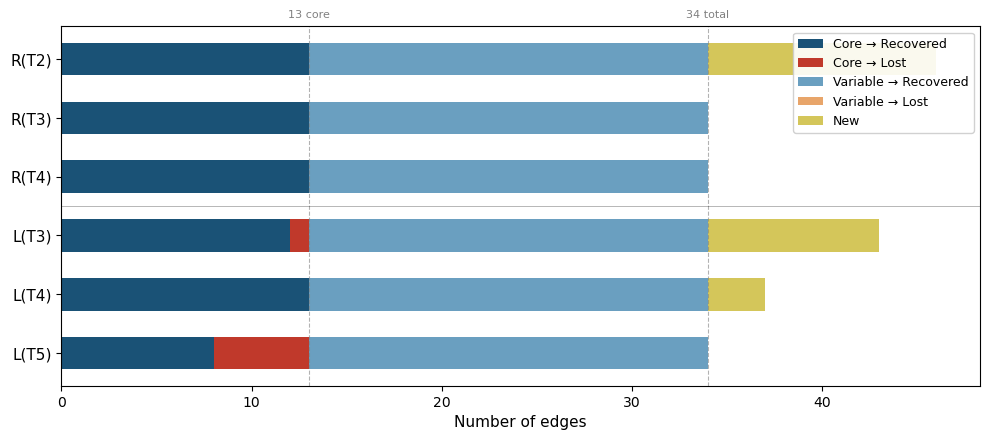

In [23]:
# ── Compute classifications ───────────────────────────────────────────────────

conditions = {
    "R(T2)": (results_complete_obs["igs"], results_RT2_missing["igs"]),
    "R(T3)": (results_complete_obs["igs"], results_RT3_missing["igs"]),
    "R(T4)": (results_complete_obs["igs"], results_RT4_missing["igs"]),
    "L(T3)": (results_complete_obs["igs"], results_LT3_missing["igs"]),
    "L(T4)": (results_complete_obs["igs"], results_LT4_missing["igs"]),
    "L(T5)": (results_complete_obs["igs"], results_LT5_missing["igs"]),
}

results_classified = {
    label: classify_edges(igs_c, igs_p)
    for label, (igs_c, igs_p) in conditions.items()
}

# ── Extract arrays ────────────────────────────────────────────────────────────

labels = list(results_classified.keys())
core_recovered     = [len(r["core_recovered"])     for r in results_classified.values()]
core_lost          = [len(r["core_lost"])           for r in results_classified.values()]
variable_recovered = [len(r["variable_recovered"]) for r in results_classified.values()]
variable_lost      = [len(r["variable_lost"])       for r in results_classified.values()]
new                = [len(r["new"])                 for r in results_classified.values()]

# Reference line values — computed from the first complete ensemble
igs_c_ref = conditions[labels[0]][0]
from collections import Counter
def _count(igs):
    c = Counter()
    for ig in igs:
        for src, tgt, data in ig.edges(data=True):
            sign = data.get("sign", data.get("weight", 1))
            c[(src, tgt, sign)] += 1
    return c
counts_ref = _count(igs_c_ref)
n_complete_ref = len(igs_c_ref)
n_core = sum(1 for c in counts_ref.values() if c == n_complete_ref)
n_var  = sum(1 for c in counts_ref.values() if 0 < c < n_complete_ref)

# ── Plot ──────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

c_core_recovered     = "#1a5276"
c_core_lost          = "#c0392b"
c_variable_recovered = "#6A9FC0"
c_variable_lost      = "#E8A56A"
c_new                = "#d4c65a"

fig, ax = plt.subplots(figsize=(10, 4.5))

y = np.arange(len(labels))
bar_height = 0.55
left = np.zeros(len(labels))

ax.barh(y, core_recovered, height=bar_height, left=left, color=c_core_recovered, label="Core → Recovered")
left += np.array(core_recovered, dtype=float)

ax.barh(y, core_lost, height=bar_height, left=left, color=c_core_lost, label="Core → Lost")
left += np.array(core_lost, dtype=float)

ax.barh(y, variable_recovered, height=bar_height, left=left, color=c_variable_recovered, label="Variable → Recovered")
left += np.array(variable_recovered, dtype=float)

ax.barh(y, variable_lost, height=bar_height, left=left, color=c_variable_lost, label="Variable → Lost")
left += np.array(variable_lost, dtype=float)

ax.barh(y, new, height=bar_height, left=left, color=c_new, label="New")

# Reference lines
ax.axvline(n_core, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(n_core + n_var, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(n_core, -0.7, f"{n_core} core", ha="center", fontsize=8, color="gray")
ax.text(n_core + n_var, -0.7, f"{n_core + n_var} total", ha="center", fontsize=8, color="gray")

# Separator between R and L holdouts
ax.axhline(2.5, color="black", linestyle="-", linewidth=0.5, alpha=0.4)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Number of edges", fontsize=11)
ax.invert_yaxis()
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

In [24]:
results_classified

{'R(T2)': {'core_recovered': {('R1_A', 'L1_A', 1),
   ('R1_A', 'L2_A', 1),
   ('R1_A', 'L3_A', 1),
   ('R1_A', 'L4_A', -1),
   ('R1_B', 'L1_B', 1),
   ('R1_B', 'L2_B', 1),
   ('R1_B', 'L3_B', -1),
   ('R1_B', 'L4_B', 1),
   ('R2_A', 'L3_A', 1),
   ('R2_B', 'L1_B', -1),
   ('R2_B', 'L2_B', -1),
   ('R2_B', 'L3_B', 1),
   ('R2_B', 'L4_B', 1)},
  'core_lost': set(),
  'variable_recovered': {('L1_A', 'R1_A', 1),
   ('L1_A', 'R1_B', -1),
   ('L1_A', 'R2_B', -1),
   ('L1_B', 'R1_A', 1),
   ('L1_B', 'R1_B', -1),
   ('L1_B', 'R2_B', 1),
   ('L2_A', 'R1_A', 1),
   ('L2_A', 'R1_B', -1),
   ('L2_A', 'R2_B', -1),
   ('L2_B', 'R1_A', 1),
   ('L2_B', 'R1_B', -1),
   ('L2_B', 'R2_B', 1),
   ('L3_A', 'R1_A', -1),
   ('L3_A', 'R1_B', -1),
   ('L3_A', 'R2_B', -1),
   ('L3_B', 'R1_A', -1),
   ('L3_B', 'R1_B', -1),
   ('L3_B', 'R2_B', -1),
   ('L4_A', 'R1_A', -1),
   ('L4_A', 'R1_B', 1),
   ('L4_A', 'R2_B', 1)},
  'variable_lost': set(),
  'new': {('L1_A', 'R2_A', -1),
   ('L1_B', 'R2_A', -1),
   ('L2_A',

In [25]:
def robustness_to_latex(results_classified, n_core, n_var, label, caption):
    latex = f"""\\begin{{table}}[h]
\\centering
\\small
\\begin{{tabular}}{{lccccc}}
\\hline
\\textbf{{Condition}} & \\textbf{{Core recovered}} & \\textbf{{Core lost}} & \\textbf{{Variable recovered}} & \\textbf{{Variable lost}} & \\textbf{{New}} \\\\
\\hline
"""
    for condition, r in results_classified.items():
        cr = len(r["core_recovered"])
        cl = len(r["core_lost"])
        vr = len(r["variable_recovered"])
        vl = len(r["variable_lost"])
        nw = len(r["new"])
        latex += f"{condition} & {cr}/{n_core} & {cl}/{n_core} & {vr}/{n_var} & {vl}/{n_var} & {nw} \\\\\n"

    latex += f"""\\hline
\\end{{tabular}}
\\caption{{{caption} Reference ensemble has {n_core} core and {n_var} variable edges ({n_core + n_var} total).}}
\\label{{{label}}}
\\end{{table}}"""
    return latex


# PSS partial — directly from your existing results_classified
print(robustness_to_latex(
    results_classified,
    n_core=n_core,
    n_var=n_var,
    label="tab:pss_partial",
    caption="Complete robustness results under PSS partial observations.",
))

\begin{table}[h]
\centering
\small
\begin{tabular}{lccccc}
\hline
\textbf{Condition} & \textbf{Core recovered} & \textbf{Core lost} & \textbf{Variable recovered} & \textbf{Variable lost} & \textbf{New} \\
\hline
R(T2) & 13/13 & 0/13 & 21/21 & 0/21 & 12 \\
R(T3) & 13/13 & 0/13 & 21/21 & 0/21 & 0 \\
R(T4) & 13/13 & 0/13 & 21/21 & 0/21 & 0 \\
L(T3) & 12/13 & 1/13 & 21/21 & 0/21 & 9 \\
L(T4) & 13/13 & 0/13 & 21/21 & 0/21 & 3 \\
L(T5) & 8/13 & 5/13 & 21/21 & 0/21 & 0 \\
\hline
\end{tabular}
\caption{Complete robustness results under PSS partial observations. Reference ensemble has 13 core and 21 variable edges (34 total).}
\label{tab:pss_partial}
\end{table}
